In [74]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

In [75]:
npr.random((1,5))

array([[0.12192038, 0.49102628, 0.97425224, 0.64148958, 0.53057485]])

In [76]:
#Simulation matrices de n*p gaussiennes réelles standards

def normal_standard(n, p) : 

    U = npr.random((n,p))
    V = npr.random((n,p))

    X = np.sqrt(-2 * np.log(U))*np.cos(2*np.pi*V)

    return X 

In [77]:
normal_standard(1,5)

array([[ 0.58766422, -0.78781756,  0.85963534,  0.04572866, -0.15201764]])

In [78]:
# Simulation d'un mouvement brownien standard de dim 1
def mouvement_brownien(T, N):
    """
    Simule une trajectoire d'un mouvement brownien standard.
    Paramètres :
    - T : temps final
    - N : nombre de pas de temps

    Retourne :
    - t : tableau des temps
    - W : tableau des valeurs du mouvement brownien
    """

    dt = T / N
    t = np.linspace(0, T, N+1)
    W = np.zeros(N+1)

    dW = np.sqrt(dt) * normal_standard(1, N)[0]

    for i in range(1, N+1):
        W[i] = W[i-1] + dW[i-1]

    return t, W

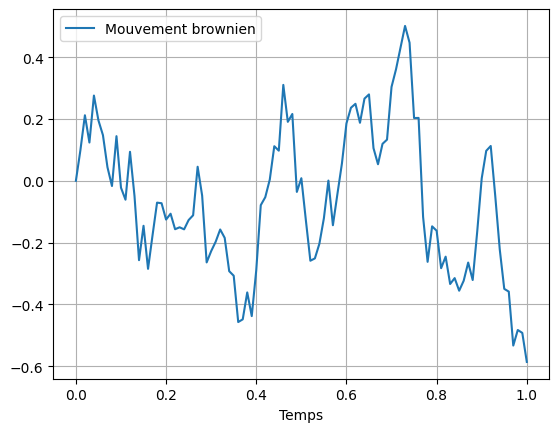

In [79]:
# Test 

t, W = mouvement_brownien(1, 100)

# Affichage
plt.plot(t, W, label='Mouvement brownien')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

In [80]:
# paramètres

T = 1.5   # Temps final
N = 1000  # Nombre de pas de temps

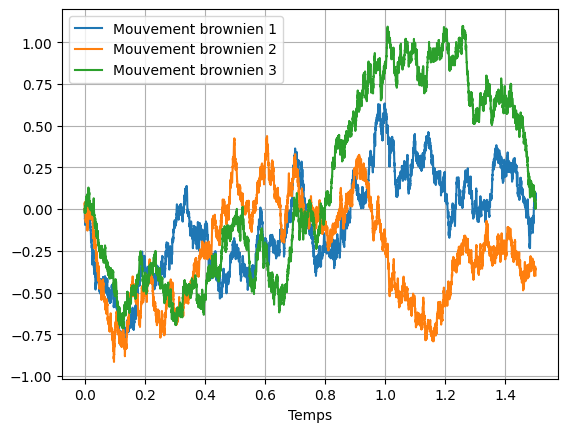

In [120]:
# Simulation des trajectoires Mouvement Bornien Standards Corrélés

def mouvement_brownien_corr(T,N,rho = 0.3) :
    Gamma = np.linalg.cholesky([[1,rho,rho],
                                [rho,1,rho],
                                [rho,rho,1]])
    # 1 : Simulation MB standards de dimension 3
    t1, W1 = mouvement_brownien(T, N)
    _, W2 = mouvement_brownien(T, N)
    _, W3 = mouvement_brownien(T, N)

    # 2 : corrélation des MB : 
    W = Gamma @ np.stack([W1, W2, W3])

    return [W[0],W[1],W[2]]

t = np.linspace(0, T, N+1)
[W1,W2,W3] = mouvement_brownien_corr(T,N)
# Affichage
plt.plot(t, W1, label='Mouvement brownien 1')
plt.plot(t, W2, label='Mouvement brownien 2')
plt.plot(t, W3, label='Mouvement brownien 3')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

In [102]:
mouvement_brownien_corr(T,1)

[array([0.        , 1.27266414]),
 array([ 0.        , -0.93576062]),
 array([0.        , 0.19461958])]

Text(0.5, 0, 'W3(T)')

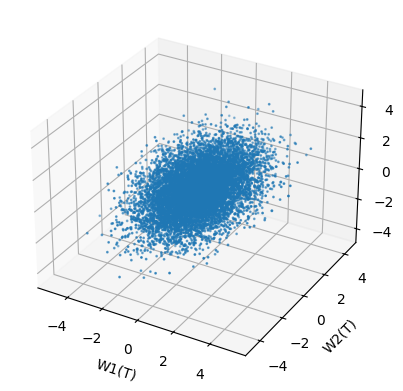

In [103]:
# Simulation du vecteur gaussien (W1(T), W2(T), W3(T)), centré, de matrice de var-cov Gamma

W1_tab = []
W2_tab = []
W3_tab = []

for _ in range (10000) :
    W = np.stack(mouvement_brownien_corr(T,1, rho=0.3))[:,1]
    W1_tab.append(W[0])
    W2_tab.append(W[1])
    W3_tab.append(W[2])

fig = plt.figure()
ax=fig.add_subplot(projection='3d')

ax.scatter(W1_tab,W2_tab,W3_tab,s=1)

ax.set_xlabel('W1(T)')
ax.set_ylabel('W2(T)')
ax.set_zlabel('W3(T)')

Text(0.5, 0, 'W3(T)')

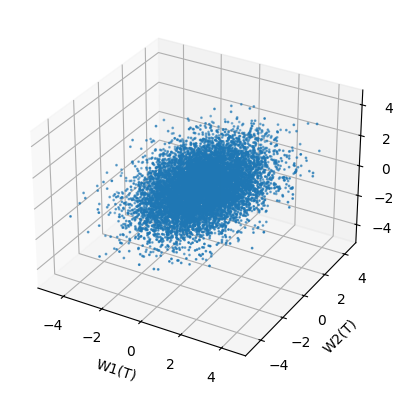

In [104]:
# Simulation du vecteur gaussien (W1(T), W2(T), W3(T)), centré, de matrice de var-cov Gamma
N = 10000
W=normal_standard(3, N)

rho = 0.3
Gamma = [[1,rho,rho],
        [rho,1,rho],
        [rho,rho,1]]

A = np.linalg.cholesky(Gamma)

B = np.sqrt(T) * A @ W 

fig = plt.figure()
ax=fig.add_subplot(projection='3d')

ax.scatter(B[0], B[1], B[2], s=1)

ax.set_xlabel('W1(T)')
ax.set_ylabel('W2(T)')
ax.set_zlabel('W3(T)')

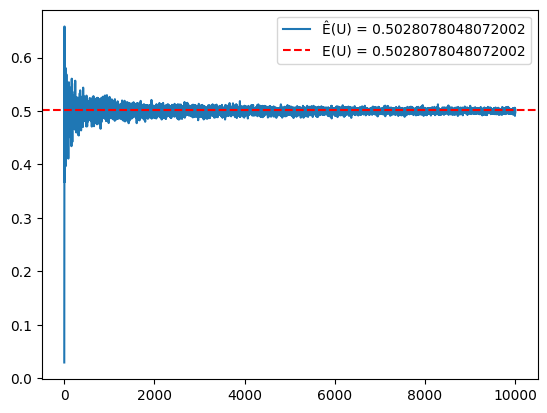

In [86]:
# test approximaton esperance de v.a. uniformes indep
N = 10000
E = np.zeros(N)

for n in range(1,N+1):
    U = np.random.uniform(0, 1, n)
    E[n-1] = (1/n) * np.sum(U)

plt.plot(np.linspace(1,N,N),E, label=f"Ê(U) = {E[-1]}" )
plt.axhline(y=np.mean(U), color='r', linestyle='--', label=f"E(U) = {np.mean(U)}")
plt.legend()
plt.show()

In [15]:
def S(t, N = N, K = 1, r = 0.02, S0 = [1,1,1], sigma = [0.3,0.3,0.3]):
    """
    Simule la solution de l'EDS de Black Scholes
    Paramètres :
    - T : temps 
    - N : nombre de pas de temps
    - K : strike de l'option (constante)
    - r : taux d'intérêt
    - S0 : conditions initiales vecteur de dim 3
    - sigma : vecteur de volatilités

    - W : mouvement brownien standards corrélés

    Retourne :
    - S : Solution de l'EDS
    """
    W1,W2,W3 = mouvement_brownien_corr(t,N)

    S1 = S0[0] * np.exp((r - (1/2)*(sigma[0])**2)*t + sigma[0]*W1)
    S2 = S0[1] * np.exp((r - (1/2)*(sigma[1])**2)*t + sigma[1]*W2)
    S3 = S0[2] * np.exp((r - (1/2)*(sigma[2])**2)*t + sigma[2]*W3)

    return S1,S2,S3

In [16]:
np.stack(S(1.5,1)) # ici on a [Si(0), Si(T)]i (il y a un seul pas de temps)

array([[0.96319442, 1.10277951],
       [0.96319442, 0.93683112],
       [0.96319442, 1.37783732]])

In [ ]:
def P1(N, T, K = 1, r = 0.02):

    # approximation de l'esperance du maxmimum
    maxi = np.zeros(N)

    for n in range(1,N+1):
        s1,s2,s3 = S(1.5, n)
        
        maxi[n-1] = np.max([s1[-1],s2[-1],s2[-1]])

    E = (1/N) * np.sum(maxi)

    return np.exp(-r * T) * (E - K)

In [53]:
def P1(N, T, K = 1, r = 0.02):
    maxSi = np.zeros(N)
    for n in range(N) : 
        ST = np.stack(S(T,1))[:,1] # np.stack permet de convertir list of array en un array of (list of list) (i.e une matrice)
        maxSi[n] = np.max(ST)

    E = (1/N)*np.sum(maxSi)
    #print(E)

    return np.exp(-r * T) * (E - K)

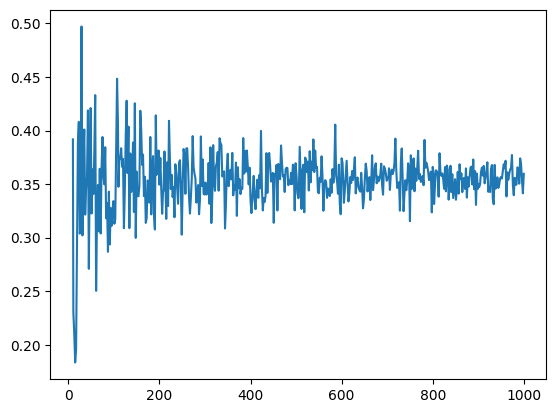

In [54]:
# test
m = 501
n = np.linspace(10,1000,m).astype(int)

P = np.zeros(m)
for i in range(m) :
    P[i] = P1(n[i],1.5)

#print(P)

plt.plot(n,P)

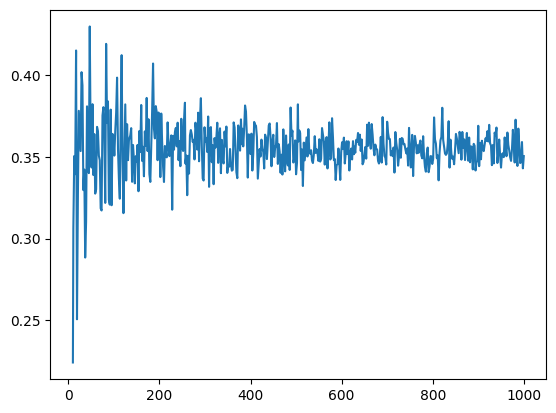

In [ ]:
T=1.5
N=100
K=1
r=0.02
S0=[1, 1, 1]
sigma=[0.3, 0.3, 0.3]

m=500

#h est telle que h(Wi(t)) = max_i Si(t)
def h(x, t, r, S0, sigma) : return np.max(S0 * np.exp((r - 0.5*sigma**2)*t + sigma*x))


######

n = np.linspace(10,1000,m).astype(int)

P = np.zeros(len(n))

for i in range(len(n)) :
    L=np.zeros(n[i])
    for j in range(n[i]) :
        W1,W2,W3 = mouvement_brownien_corr(T,1)

        # W(T) ( i.e on garde la composante T de t |---> W_i (t) pr tt i) : 
        WT = [W1[-1], W2[-1], W3[-1]]

        V = 0.5 * (h(np.array(WT), T, r, np.array(S0), np.array(sigma)) + h(-np.array(WT), T, r, np.array(S0), np.array(sigma)))
        L[j] = V
    E = (1/n[i])*sum(L)
    P[i] = np.exp(-r * T) * (E - K)

plt.plot(n,P)


In [48]:
np.zeros(1)

array([0.])